Team Name : SG

Team members - VENKATESH KARDILE - SANSKRUTI GHADGE - SAMMED KARAV - JANHAVI YADAV - GENDAMALU MAHALAKSHMI

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime, pickle, warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set(style="ticks")

In [6]:
# Load the Data
train_df = pd.read_csv("CS98XRegressionTrain.csv")
test_df  = pd.read_csv("CS98XRegressionTest.csv")

In [7]:
# Display the first few rows of both data set
print(train_df.head())
print(test_df.head())

   Id                                        title            artist  \
0   1                                 My Happiness    Connie Francis   
1   2                             Unchained Melody   The Teddy Bears   
2   3                        How Deep Is Your Love          Bee Gees   
3   4                                Woman in Love  Barbra Streisand   
4   5  Goodbye Yellow Brick Road - Remastered 2014        Elton John   

         top genre  year  bpm  nrgy  dnce  dB  live  val  dur  acous  spch  \
0  adult standards  1996  107    31    45  -8    13   28  150     75     3   
1              NaN  2011  114    44    53  -8    13   47  139     49     3   
2  adult standards  1979  105    36    63  -9    13   67  245     11     3   
3  adult standards  1980  170    28    47 -16    13   33  232     25     3   
4        glam rock  1973  121    47    56  -8    15   40  193     45     3   

   pop  
0   44  
1   37  
2   77  
3   67  
4   63  
    Id                                      

In [8]:
# EDA: Top Genre Distribution with a Stacked Bar Chart
# Fill missing values in 'top genre'
train_df['top genre'] = train_df['top genre'].fillna(train_df['top genre'].mode()[0])

# Convert the 'top genre' column to lowercase for consistent string matching
train_df['top genre'] = train_df['top genre'].str.lower()

# Define conditions for each genre category
conditions = [
    train_df['top genre'].str.contains("pop", na=False),
    train_df['top genre'].str.contains("rock", na=False),
    (train_df['top genre'].str.contains("adult", na=False)) & (train_df['top genre'].str.contains("standard", na=False))
]

# Corresponding choices for each condition
choices = ["pop", "rock", "adult_standards"]

# Use numpy.select to assign a category based on the conditions
train_df['broad_genre'] = np.select(conditions, choices, default="other")


# Define bins and corresponding labels for decades
bins = [0, 1979, 1989, 1999, 2009, float('inf')]
labels = [1970, 1980, 1990, 2000, 2010]

# Create the 'decade' column using pd.cut
train_df['decade'] = pd.cut(train_df['year'], bins=bins, labels=labels, right=True)

# Group by decade and broad_genre and unstack to create a table
genre_decade = train_df.groupby(['decade', 'broad_genre']).size().unstack().fillna(0)


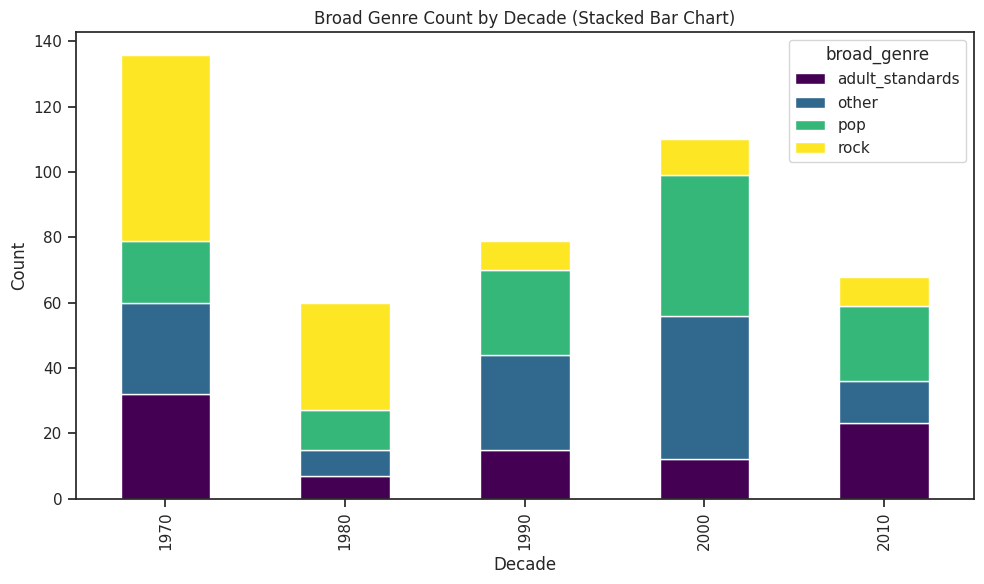

In [9]:
plt.figure(figsize=(10,6))
genre_decade.plot(kind='bar', stacked=True, colormap="viridis", ax=plt.gca())
plt.xlabel("Decade")
plt.ylabel("Count")
plt.title("Broad Genre Count by Decade (Stacked Bar Chart)")
plt.tight_layout()
plt.show()


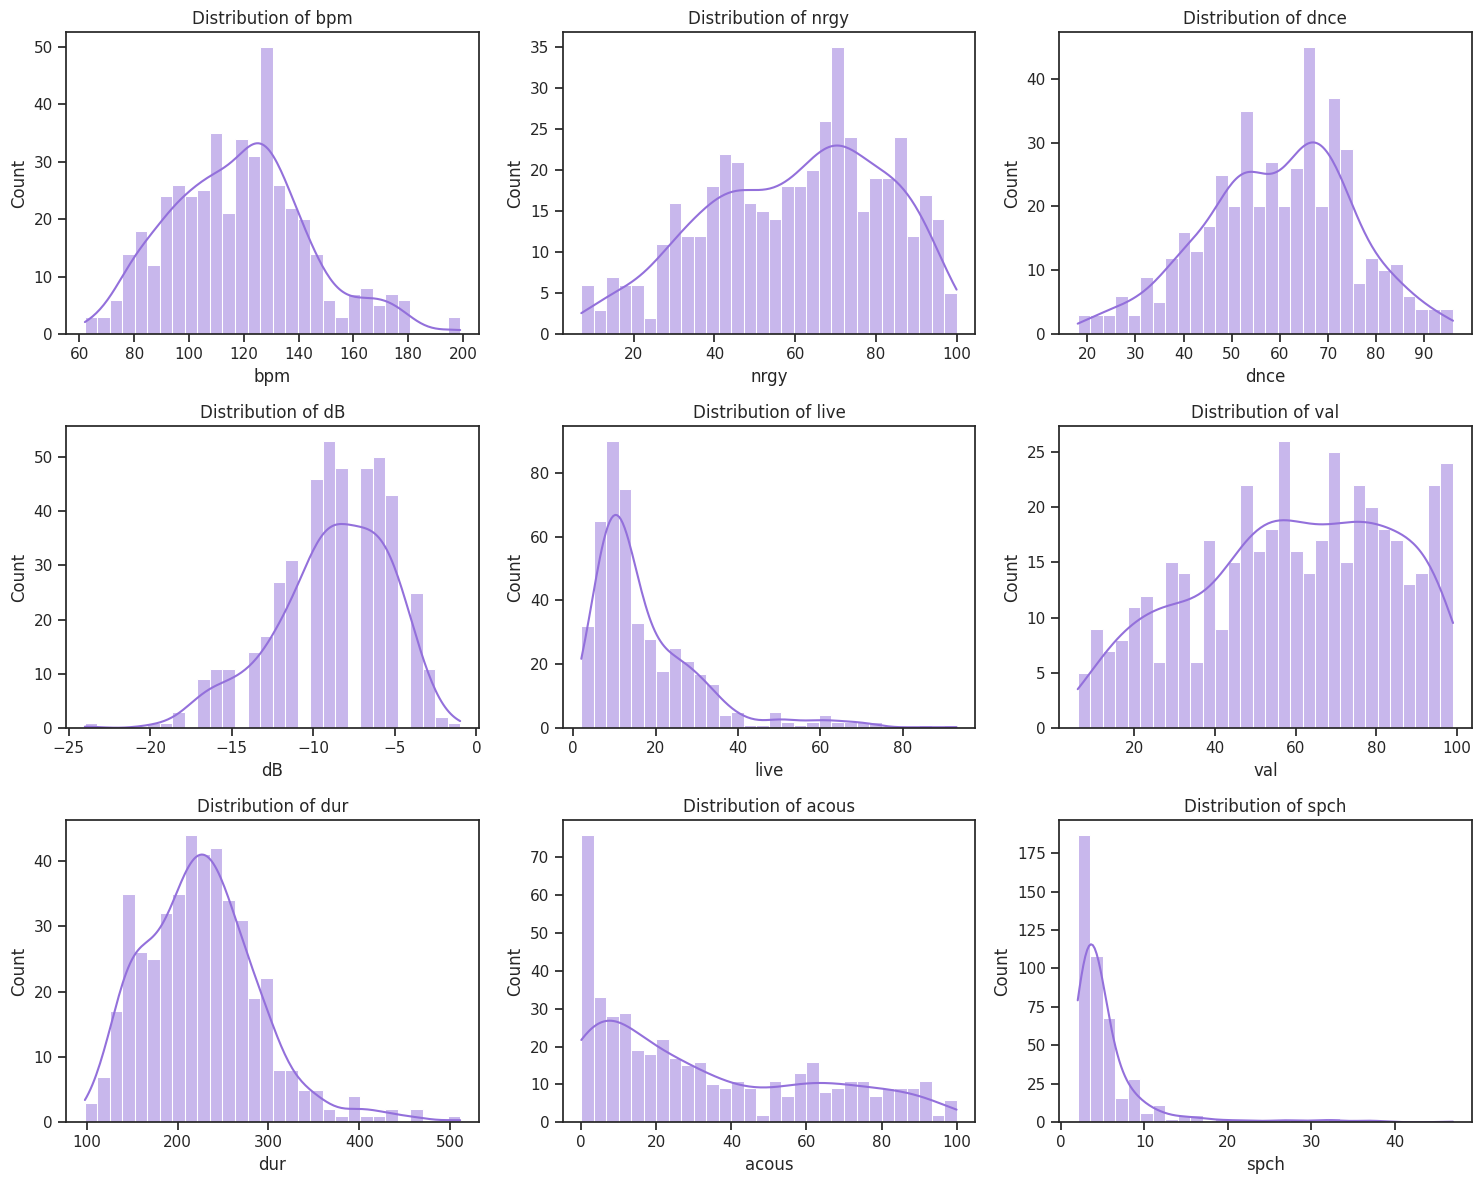

In [10]:
# Additional EDA: Distributions and Correlations
cont_features = ['bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch']
plt.figure(figsize=(15,12))
for i, col in enumerate(cont_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(train_df[col], kde=True, color='mediumpurple', bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

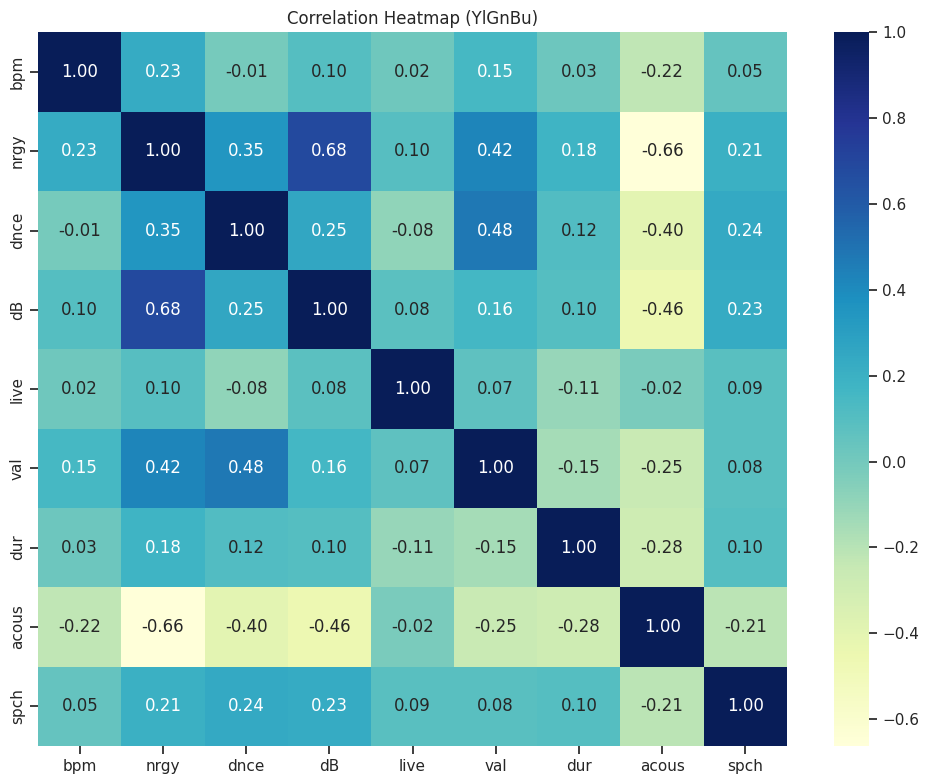

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(train_df[cont_features].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap (YlGnBu)")
plt.tight_layout()
plt.show()

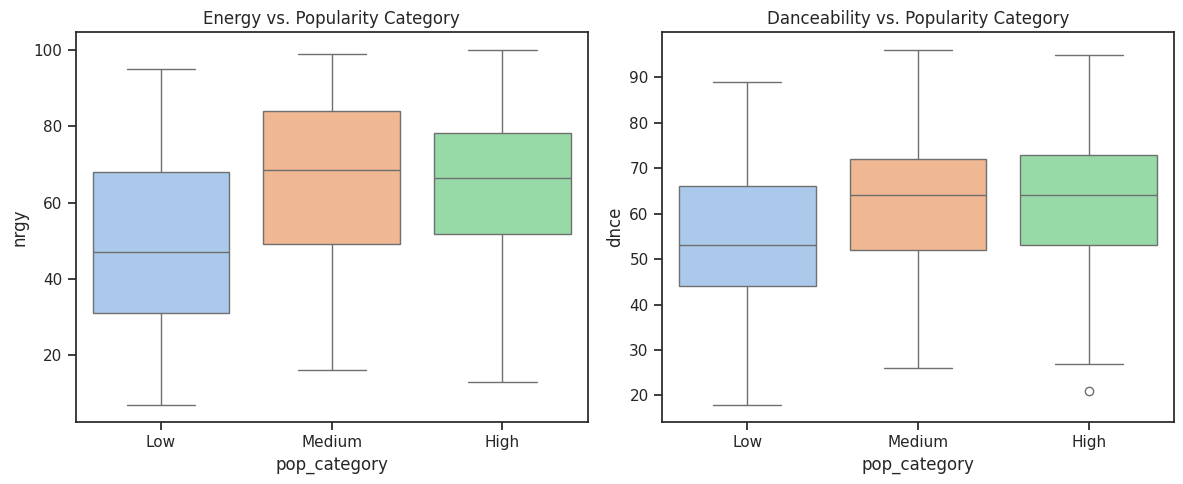

In [12]:
# Additional EDA: Categorical Popularity and Genre Distributions
pop_quant = train_df['pop'].quantile([0.30, 0.60])
bins = [-1, pop_quant.loc[0.30], pop_quant.loc[0.60], 100]
labels = ['Low', 'Medium', 'High']
train_df['pop_category'] = pd.cut(train_df['pop'], bins=bins, labels=labels)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='pop_category', y='nrgy', data=train_df, palette="pastel")
plt.title("Energy vs. Popularity Category")

plt.subplot(1,2,2)
sns.boxplot(x='pop_category', y='dnce', data=train_df, palette="pastel")
plt.title("Danceability vs. Popularity Category")

plt.tight_layout()
plt.show()


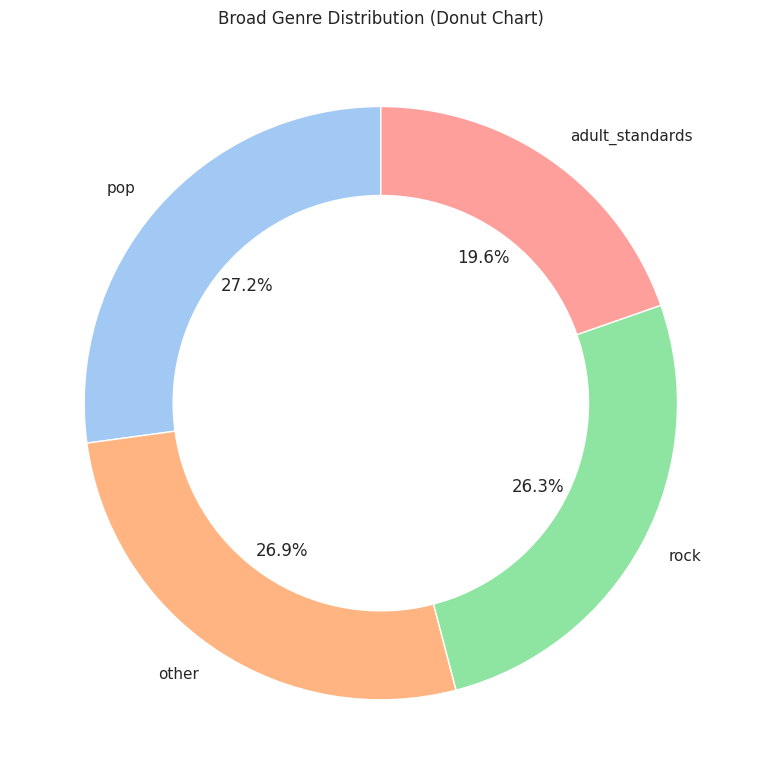

In [13]:
plt.figure(figsize=(8,8))
broad_genre_counts = train_df['broad_genre'].value_counts()
colors = sns.color_palette("pastel", len(broad_genre_counts))
plt.pie(broad_genre_counts, labels=broad_genre_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
# Create a white circle at the center to convert it into a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Broad Genre Distribution (Donut Chart)")
plt.tight_layout()
plt.show()


In [14]:
# Helper function to bin a value based on given thresholds and labels
def bin_value(val, thresholds, labels):

    for threshold, label in zip(thresholds, labels):
        if val < threshold:
            return label
    # If value exceeds all thresholds, return the last label.
    return labels[-1]

# Specific binning functions using the helper function

def bin_live(val):
    thresholds = [10, 15, 30]
    labels = [1, 2, 3, 4]
    return bin_value(val, thresholds, labels)

def bin_spch(val):
    thresholds = [3, 5]
    labels = [1, 2, 3]
    return bin_value(val, thresholds, labels)


In [15]:
train_df['live_cat'] = train_df['live'].apply(bin_live)
train_df['spch_cat'] = train_df['spch'].apply(bin_spch)

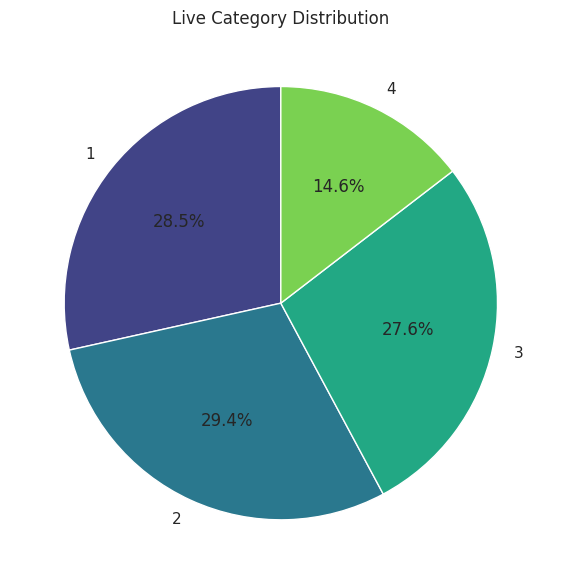

In [16]:
live_counts = train_df['live_cat'].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(live_counts, labels=live_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette("viridis", len(live_counts)), startangle=90)
plt.title("Live Category Distribution")
plt.tight_layout()
plt.show()



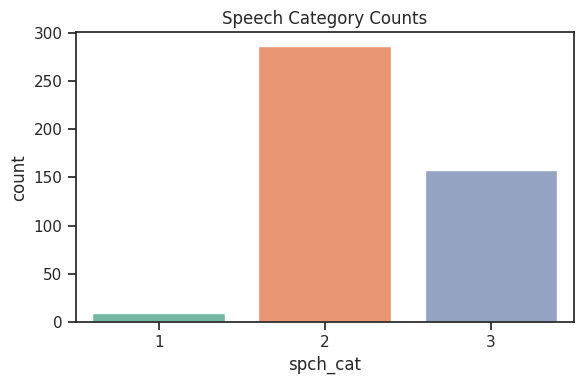

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='spch_cat', data=train_df, palette="Set2")
plt.title("Speech Category Counts")
plt.tight_layout()
plt.show()


In [18]:
current_year = datetime.datetime.now().year
train_df['years_since'] = current_year - train_df['year']


In [19]:
# Common Preprocessing for Modeling (RF, XGB, & Stacking)
features = ['bpm', 'nrgy', 'dnce', 'dB', 'val', 'dur', 'acous',
            'broad_genre', 'live_cat', 'spch_cat', 'years_since']
model_data = train_df[features].copy()
target = train_df['pop']

In [20]:
# One-hot encode categorical features
model_data = pd.get_dummies(model_data, columns=['broad_genre', 'live_cat', 'spch_cat'], drop_first=True)


In [21]:
# Scale features
scaler = StandardScaler()
model_data_scaled = pd.DataFrame(scaler.fit_transform(model_data), columns=model_data.columns)


In [22]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(model_data_scaled, target, test_size=0.25, random_state=100)


In [23]:
# Fine-Tuned Random Forest using GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 7, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
base_rf = RandomForestRegressor(random_state=100)
rf_grid = GridSearchCV(estimator=base_rf, param_grid=rf_param_grid,
                       scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print("Random Forest - Best parameters:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_
rf_train_rmse = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))
rf_val_rmse = np.sqrt(mean_squared_error(y_val, best_rf.predict(X_val)))
print("Random Forest RMSE - Train:", rf_train_rmse)
print("Random Forest RMSE - Validation:", rf_val_rmse)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Random Forest - Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest RMSE - Train: 5.387751446255904
Random Forest RMSE - Validation: 10.601214280230186


In [24]:
# Fine-Tuned XGBoost using GridSearchCV
xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
base_xgb = xgb.XGBRegressor(random_state=100, objective='reg:squarederror', verbosity=0)
xgb_grid = GridSearchCV(estimator=base_xgb, param_grid=xgb_param_grid,
                        scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

print("XGBoost - Best parameters:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, best_xgb.predict(X_train)))
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, best_xgb.predict(X_val)))
print("XGBoost RMSE - Train:", xgb_train_rmse)
print("XGBoost RMSE - Validation:", xgb_val_rmse)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
XGBoost - Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
XGBoost RMSE - Train: 5.325888066271953
XGBoost RMSE - Validation: 10.887471731786459


In [25]:
# Stacking Ensemble: Combine Random Forest and XGBoost
estimators = [
    ('rf', best_rf),
    ('xgb', best_xgb)
]

stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)
stacking_reg.fit(X_train, y_train)

stack_train_rmse = np.sqrt(mean_squared_error(y_train, stacking_reg.predict(X_train)))
stack_val_rmse = np.sqrt(mean_squared_error(y_val, stacking_reg.predict(X_val)))
print("Stacking Ensemble RMSE - Train:", stack_train_rmse)
print("Stacking Ensemble RMSE - Validation:", stack_val_rmse)

Stacking Ensemble RMSE - Train: 5.399439297756303
Stacking Ensemble RMSE - Validation: 10.70174686192766


In [26]:
# Save Models and Scaler for Future Predictions
with open("rf_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
with open("stacking_model.pkl", "wb") as f:
    pickle.dump(stacking_reg, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [27]:
def simplify_genre(genre):
    genre = str(genre).lower()  # Convert to lowercase for consistency
    if "pop" in genre:
        return "pop"
    elif "rock" in genre:
        return "rock"
    elif "adult" in genre and "standards" in genre:
        return "adult_standards"
    else:
        return "other"# Function to preprocess test data using the same pipeline
def preprocess_test_data(test_df, scaler_obj, ref_columns):
    test_df['top genre'] = test_df['top genre'].fillna(test_df['top genre'].mode()[0])
    test_df['broad_genre'] = test_df['top genre'].apply(simplify_genre)
    test_df['live_cat'] = test_df['live'].apply(bin_live)
    test_df['spch_cat'] = test_df['spch'].apply(bin_spch)
    test_df['years_since'] = current_year - test_df['year']

    test_features = test_df[['bpm', 'nrgy', 'dnce', 'dB', 'val', 'dur', 'acous',
                               'broad_genre', 'live_cat', 'spch_cat', 'years_since']].copy()
    test_features = pd.get_dummies(test_features, columns=['broad_genre', 'live_cat', 'spch_cat'], drop_first=True)
    test_features = test_features.reindex(columns=ref_columns, fill_value=0)
    test_scaled = pd.DataFrame(scaler_obj.transform(test_features), columns=test_features.columns)
    return test_scaled

In [28]:
# Preprocess test data using the same feature columns as model_data
test_features_scaled = preprocess_test_data(test_df, scaler, model_data.columns)
test_preds_stack = stacking_reg.predict(test_features_scaled)
submission_stack = pd.DataFrame({"Id": test_df["Id"], "pop": test_preds_stack})
submission_stack.to_csv("stacking_predictions.csv", index=False)
test_preds_rf = best_rf.predict(test_features_scaled)
submission_rf = pd.DataFrame({"Id": test_df["Id"], "pop": test_preds_rf})
submission_rf.to_csv("random_forest_predictions.csv", index=False)

test_preds_xgb = best_xgb.predict(test_features_scaled)
submission_xgb = pd.DataFrame({"Id": test_df["Id"], "pop": test_preds_xgb})
submission_xgb.to_csv("xgboost_predictions.csv", index=False)

In [29]:
# Model Performance Summary Table
performance_summary = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Stacking Ensemble"],
    "RMSE_Train": [rf_train_rmse, xgb_train_rmse, stack_train_rmse],
    "RMSE_Validation": [rf_val_rmse, xgb_val_rmse, stack_val_rmse]
})
print(performance_summary)


               Model  RMSE_Train  RMSE_Validation
0      Random Forest    5.387751        10.601214
1            XGBoost    5.325888        10.887472
2  Stacking Ensemble    5.399439        10.701747
